
1. LOAD THE WINE DATASET

Full DataFrame:
     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     fla

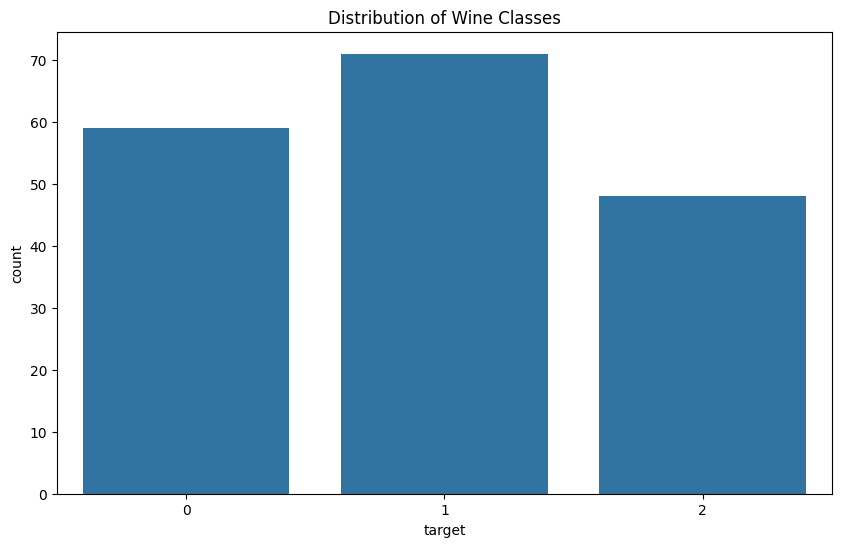


Training shape: (142, 13)
Testing shape: (36, 13)

KNN CLASSIFICATION RESULTS
Accuracy: 0.9444444444444444

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.86      0.92        14
           2       0.89      1.00      0.94         8

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.94        36
weighted avg       0.95      0.94      0.94        36


2. CAR PRICES DATASET (GENERATED)

Full DataFrame:
   Mileage  Age  Horsepower  Price
0    50000    5         130  15000
1    30000    3         150  20000
2    70000    7         120  12000
3    20000    2         160  25000
4    90000    9         110  10000
5    40000    4         140  18000
6    60000    6         125  14000
7    80000    8         115   9000

First 5 rows:
   Mileage  Age  Horsepower  Price
0    50000    5         130  15000
1    30000    3         150  20000


In [2]:
# ============================================================
# MACHINE LEARNING: CLASSIFICATION (WINE) + REGRESSION (CARS)
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# ============================================================
# PART 1 — CLASSIFICATION WITH WINE DATASET
# ============================================================

print("\n==============================")
print("1. LOAD THE WINE DATASET")
print("==============================")

wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine["target"] = wine.target

print("\nFull DataFrame:")
print(df_wine)

print("\nFirst 5 rows:")
print(df_wine.head())


# -------------------------------
# Basic Visualization
# -------------------------------
plt.figure(figsize=(10, 6))
sns.countplot(x=df_wine["target"])
plt.title("Distribution of Wine Classes")
plt.show()


# -------------------------------
# Split the Data
# -------------------------------
X = df_wine.drop("target", axis=1)
y = df_wine["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)


# -------------------------------
# Feature Scaling
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# -------------------------------
# Train KNN Classifier
# -------------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predict
y_pred = knn.predict(X_test_scaled)

# Evaluate
print("\n==============================")
print("KNN CLASSIFICATION RESULTS")
print("==============================")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ============================================================
# PART 2 — REGRESSION WITH CAR PRICES DATASET
# ============================================================

print("\n==============================")
print("2. CAR PRICES DATASET (GENERATED)")
print("==============================")

df_cars = pd.DataFrame({
    "Mileage": [50000, 30000, 70000, 20000, 90000, 40000, 60000, 80000],
    "Age": [5, 3, 7, 2, 9, 4, 6, 8],
    "Horsepower": [130, 150, 120, 160, 110, 140, 125, 115],
    "Price": [15000, 20000, 12000, 25000, 10000, 18000, 14000, 9000]
})

print("\nFull DataFrame:")
print(df_cars)

print("\nFirst 5 rows:")
print(df_cars.head())


# -------------------------------
# Split the Data
# -------------------------------
X_car = df_cars.drop("Price", axis=1)
y_car = df_cars["Price"]

X_train_car, X_test_car, y_train_car, y_test_car = train_test_split(
    X_car, y_car, test_size=0.25, random_state=42
)

print("\nTraining shape:", X_train_car.shape)
print("Testing shape:", X_test_car.shape)


# -------------------------------
# Train Linear Regression Model
# -------------------------------
model = LinearRegression()
model.fit(X_train_car, y_train_car)

# Predict
y_pred_car = model.predict(X_test_car)

# Evaluate
mse = mean_squared_error(y_test_car, y_pred_car)
r2 = r2_score(y_test_car, y_pred_car)

print("\n==============================")
print("LINEAR REGRESSION RESULTS")
print("==============================")
print("Mean Squared Error:", mse)
print("R² Score:", r2)